# XGBoost Probabilistic Forecasting with Daily Rolling Retraining (ERCOT Dallas)

This notebook implements the rolling retraining benchmark for ERCOT Dallas. Unlike the static benchmark, we retrain the XGBoost models at the start of each forecast day using a sliding 2-year historical window. This avoids model outdatedness and ensures absolute comparability against zero-shot foundation models (like Chronos-2) which are always given the immediate past context.

In [1]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

HORIZON = 24

In [2]:
def load_ercot_data():
    files = sorted(glob.glob('../../data/ercot/raw/ercot_20*.xlsx'))
    dfs = []
    for f in files:
        df = pd.read_excel(f)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    
    def parse_ercot_datetime(s):
        s = str(s).replace(' DST', '')
        if s.endswith('24:00'):
            return pd.to_datetime(s.replace('24:00', '00:00')) + pd.Timedelta(days=1) - pd.Timedelta(hours=1)
        else:
            return pd.to_datetime(s) - pd.Timedelta(hours=1)

    df['timestamp'] = df['Hour Ending'].apply(parse_ercot_datetime)
    df = df[['timestamp', 'NCENT']].copy()
    df.rename(columns={'NCENT': 'target'}, inplace=True)
    df = df.sort_values('timestamp').set_index('timestamp')
    df = df.resample('h').mean()
    df['target'] = df['target'].interpolate()
    return df

def load_weather_data():
    files = sorted(glob.glob('../../data/ercot/raw/open-meteo-dallas-*.csv'))
    dfs = []
    for f in files:
        df_w = pd.read_csv(f, skiprows=3)
        dfs.append(df_w)
    df_w = pd.concat(dfs, ignore_index=True)
    
    df_w['timestamp'] = pd.to_datetime(df_w['time'])
    df_w = df_w.rename(columns={
        'temperature_2m (°C)': 'temp',
        'relative_humidity_2m (%)': 'humidity',
        'dew_point_2m (°C)': 'dew_point',
        'apparent_temperature (°C)': 'apparent_temp',
        'wind_speed_10m (km/h)': 'wind_speed',
        'cloud_cover (%)': 'cloud_cover',
        'precipitation (mm)': 'precip',
        'shortwave_radiation (W/m²)': 'radiation'
    })
    
    cols = ['timestamp', 'temp', 'humidity', 'dew_point', 'apparent_temp', 'wind_speed', 'cloud_cover', 'precip', 'radiation']
    df_w = df_w[cols].set_index('timestamp')
    df_w = df_w.resample('h').mean().interpolate()
    return df_w

df_load = load_ercot_data()
df_weather = load_weather_data()
df = df_load.join(df_weather, how='inner')
print(f"Merged data from {df.index.min()} to {df.index.max()}")

# Pre-compute rolling features on target load
for w in [6, 12, 24]:
    df[f'load_roll_mean_{w}h'] = df['target'].rolling(window=w).mean()
    df[f'load_roll_min_{w}h'] = df['target'].rolling(window=w).min()
    df[f'load_roll_max_{w}h'] = df['target'].rolling(window=w).max()
    df[f'load_roll_std_{w}h'] = df['target'].rolling(window=w).std()

# Pre-compute rolling features on weather variables
for w in [3, 6, 12, 48, 72]:
    df[f'temp_roll_mean_{w}h'] = df['temp'].rolling(window=w).mean()
    df[f'apparent_temp_roll_mean_{w}h'] = df['apparent_temp'].rolling(window=w).mean()
    df[f'radiation_roll_mean_{w}h'] = df['radiation'].rolling(window=w).mean()

# Degree days and weather interactions
df['cdd'] = (df['temp'] - 18.33).clip(lower=0)
df['hdd'] = (18.33 - df['temp']).clip(lower=0)
df['apparent_cdd'] = (df['apparent_temp'] - 18.33).clip(lower=0)
df['temp_humidity_interaction'] = df['temp'] * df['humidity']

Merged data from 2023-01-01 00:00:00 to 2026-03-31 23:00:00


In [3]:
tx_holidays = holidays.US(state='TX')

def get_calendar_features(dt_index):
    features = pd.DataFrame(index=dt_index)
    features['hour'] = dt_index.hour
    features['dayofweek'] = dt_index.dayofweek
    features['is_weekend'] = (dt_index.dayofweek >= 5).astype(int)
    features['month'] = dt_index.month
    features['is_holiday'] = pd.Series(dt_index).apply(lambda x: x in tx_holidays).values.astype(int)
    return features

In [4]:
# Feature configurations
lag_cols = ['feat_origin', 'feat_origin_m1', 'feat_origin_m2', 
            'feat_24h_aligned', 'feat_48h_aligned', 'feat_168h_aligned']

roll_load_cols = []
for w in [6, 12, 24]:
    roll_load_cols.extend([f'load_roll_mean_{w}h', f'load_roll_min_{w}h', 
                           f'load_roll_max_{w}h', f'load_roll_std_{w}h'])

cal_cols = ['target_hour', 'target_dayofweek', 'target_is_weekend', 'target_month', 'target_is_holiday']

weather_cols = ['target_temp', 'target_humidity', 'target_dew_point', 'target_apparent_temp', 
                'target_wind_speed', 'target_cloud_cover', 'target_precip', 'target_radiation']

degree_cols = ['target_cdd', 'target_hdd', 'target_apparent_cdd']

roll_weather_cols = []
for w in [3, 6, 12, 48, 72]:
    roll_weather_cols.extend([f'target_temp_roll_mean_{w}h', 
                              f'target_apparent_temp_roll_mean_{w}h', 
                              f'target_radiation_roll_mean_{w}h'])

interaction_cols = ['target_temp_humidity_interaction', 'target_temp_hour_interaction']

feature_cols = lag_cols + roll_load_cols + cal_cols + weather_cols + degree_cols + roll_weather_cols + interaction_cols

# Pre-build df_h dataframes for each horizon
df_h_dict = {}
for h in range(1, HORIZON + 1):
    df_h = df.copy()
    
    df_h['feat_origin'] = df_h['target']
    df_h['feat_origin_m1'] = df_h['target'].shift(1)
    df_h['feat_origin_m2'] = df_h['target'].shift(2)
    df_h['feat_24h_aligned'] = df_h['target'].shift(24 - h)
    df_h['feat_48h_aligned'] = df_h['target'].shift(48 - h)
    df_h['feat_168h_aligned'] = df_h['target'].shift(168 - h)
    
    df_h['target_h'] = df_h['target'].shift(-h)
    df_h['residual_target_h'] = df_h['target_h'] - df_h['feat_24h_aligned']
    
    target_times = df_h.index + pd.Timedelta(hours=h)
    cal_feats = get_calendar_features(target_times)
    df_h['target_hour'] = cal_feats['hour'].values
    df_h['target_dayofweek'] = cal_feats['dayofweek'].values
    df_h['target_is_weekend'] = cal_feats['is_weekend'].values
    df_h['target_month'] = cal_feats['month'].values
    df_h['target_is_holiday'] = cal_feats['is_holiday'].values
    
    df_h['target_temp'] = df_h['temp'].shift(-h)
    df_h['target_humidity'] = df_h['humidity'].shift(-h)
    df_h['target_dew_point'] = df_h['dew_point'].shift(-h)
    df_h['target_apparent_temp'] = df_h['apparent_temp'].shift(-h)
    df_h['target_wind_speed'] = df_h['wind_speed'].shift(-h)
    df_h['target_cloud_cover'] = df_h['cloud_cover'].shift(-h)
    df_h['target_precip'] = df_h['precip'].shift(-h)
    df_h['target_radiation'] = df_h['radiation'].shift(-h)
    
    df_h['target_cdd'] = df_h['cdd'].shift(-h)
    df_h['target_hdd'] = df_h['hdd'].shift(-h)
    df_h['target_apparent_cdd'] = df_h['apparent_cdd'].shift(-h)
    
    for w in [3, 6, 12, 48, 72]:
        df_h[f'target_temp_roll_mean_{w}h'] = df_h[f'temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_apparent_temp_roll_mean_{w}h'] = df_h[f'apparent_temp_roll_mean_{w}h'].shift(-h)
        df_h[f'target_radiation_roll_mean_{w}h'] = df_h[f'radiation_roll_mean_{w}h'].shift(-h)
        
    df_h['target_temp_humidity_interaction'] = df_h['temp_humidity_interaction'].shift(-h)
    df_h['target_temp_hour_interaction'] = df_h['target_temp'] * df_h['target_hour']
    
    df_h = df_h.dropna()
    df_h_dict[h] = df_h

In [5]:
def evaluate_rolling_xgboost(test_df, df_h_dict):
    all_preds = []
    all_actuals = []
    all_lowers = []
    all_uppers = []
    origins = test_df[test_df.index.hour == 0].index
    for day_idx, origin in enumerate(origins):
        if origin + pd.Timedelta(hours=24) > test_df.index[-1]:
            continue
        actual = test_df.loc[origin + pd.Timedelta(hours=1) : origin + pd.Timedelta(hours=24), 'target'].values
        
        # Train sliding window 2 years before origin
        train_start = origin - pd.DateOffset(years=2)
        
        preds = []
        lowers = []
        uppers = []
        for h in range(1, 25):
            df_h = df_h_dict[h]
            # Target T'+h is only known if target timestamp <= origin T
            train_end = origin - pd.Timedelta(hours=h)
            train_h = df_h.loc[train_start:train_end]
            
            val_size = int(len(train_h) * 0.15)
            train_split = train_h.iloc[:-val_size]
            val_split = train_h.iloc[-val_size:]
            
            # Fit Point Model
            m_point = xgb.XGBRegressor(
                n_estimators=1000,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.6,
                reg_lambda=3.0,
                reg_alpha=0.5,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            m_point.fit(
                train_split[feature_cols].astype(float), 
                train_split['residual_target_h'],
                eval_set=[(val_split[feature_cols].astype(float), val_split['residual_target_h'])],
                verbose=False
            )
            
            # Fit Quantile Model
            m_quant = xgb.XGBRegressor(
                objective='reg:quantileerror',
                quantile_alpha=[0.05, 0.95],
                n_estimators=1000,
                learning_rate=0.03,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.6,
                reg_lambda=3.0,
                reg_alpha=0.5,
                early_stopping_rounds=30,
                random_state=42,
                n_jobs=-1
            )
            m_quant.fit(
                train_split[feature_cols].astype(float), 
                train_split['residual_target_h'],
                eval_set=[(val_split[feature_cols].astype(float), val_split['residual_target_h'])],
                verbose=False
            )
            
            # Predict for origin
            feats = df_h.loc[[origin]]
            feat_24h_aligned = feats['feat_24h_aligned'].values[0]
            
            pred_residual = m_point.predict(feats[feature_cols].astype(float))[0]
            pred_raw = pred_residual + feat_24h_aligned
            preds.append(pred_raw)
            
            quantiles_residual = m_quant.predict(feats[feature_cols].astype(float))[0]
            lower_raw = quantiles_residual[0] + feat_24h_aligned
            upper_raw = quantiles_residual[1] + feat_24h_aligned
            lowers.append(lower_raw)
            uppers.append(upper_raw)

        all_preds.append(preds)
        all_actuals.append(actual)
        all_lowers.append(lowers)
        all_uppers.append(uppers)
        if (day_idx + 1) % 5 == 0 or (day_idx + 1) == len(origins):
            print(f"Processed day {day_idx + 1}/{len(origins)}")
    return np.array(all_actuals), np.array(all_preds), np.array(all_lowers), np.array(all_uppers)

In [6]:
def calculate_metrics(y_true, y_pred, y_train, y_lower=None, y_upper=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true)))
    mae_naive = mean_absolute_error(y_train[168:], y_train[:-168])
    mase = mae / mae_naive
    
    metrics = {'MAE': mae, 'RMSE': rmse, 'sMAPE': smape, 'MASE': mase}
    if y_lower is not None and y_upper is not None:
        inside = (y_true >= y_lower) & (y_true <= y_upper)
        metrics['Coverage'] = 100 * np.mean(inside)
    return metrics

aug_df = df['2025-08-01 00:00:00':'2025-08-31 23:00:00']
mar_df = df['2026-03-01 00:00:00':'2026-03-31 23:00:00']

results = {}
for window_name, test_df in [("August 2025", aug_df), ("March 2026", mar_df)]:
    print(f"\nEvaluating {window_name}...")
    act, p_dir, p_lower, p_upper = evaluate_rolling_xgboost(test_df, df_h_dict)
    results[window_name] = (act, p_dir, p_lower, p_upper)
    # train_df target variable used for naive calculation baseline
    train_df = df[:test_df.index[0] - pd.Timedelta(hours=1)]
    metrics = calculate_metrics(act.flatten(), p_dir.flatten(), train_df['target'], p_lower.flatten(), p_upper.flatten())
    print(f"\nResults for {window_name} (XGBoost Rolling Retraining):")
    print(metrics)


Evaluating August 2025...


Processed day 5/31


Processed day 10/31


Processed day 15/31


Processed day 20/31


...

Processed day 10/31


Processed day 15/31


Processed day 20/31


Processed day 25/31


Processed day 30/31

Results for March 2026 (XGBoost Rolling Retraining):
{'MAE': 471.37988861992545, 'RMSE': np.float64(608.0301477542337), 'sMAPE': np.float64(3.5235591485338857), 'MASE': 0.2480690363234059, 'Coverage': np.float64(83.88888888888889)}


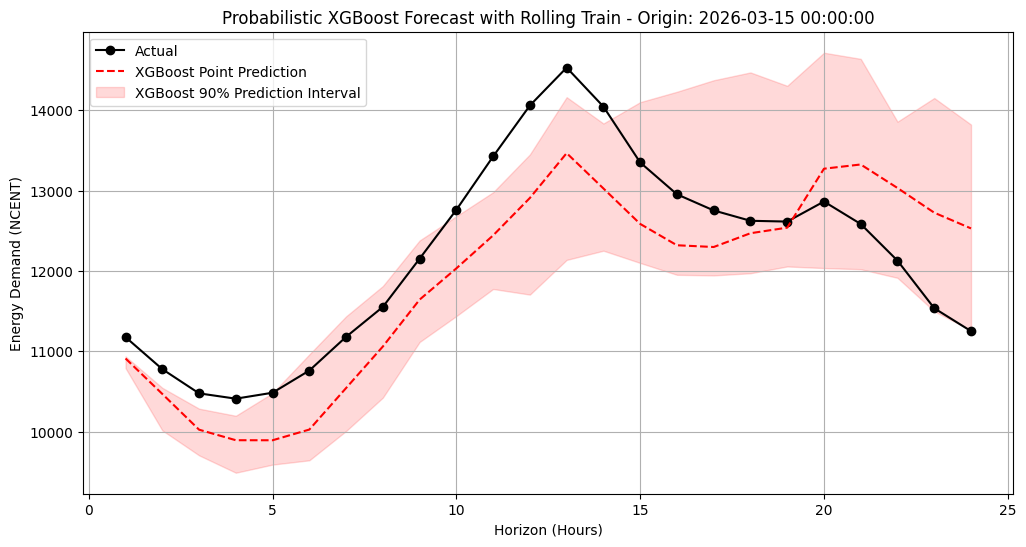

In [7]:
sample_origin = '2026-03-15 00:00:00'
origin_ts = pd.Timestamp(sample_origin)
origins = mar_df[mar_df.index.hour == 0].index
sample_idx = list(origins).index(origin_ts)

act_sample = results['March 2026'][0][sample_idx]
wea_preds = results['March 2026'][1][sample_idx]
wea_lowers = results['March 2026'][2][sample_idx]
wea_uppers = results['March 2026'][3][sample_idx]

plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), act_sample, label='Actual', marker='o', color='black')
plt.plot(range(1, 25), wea_preds, label='XGBoost Point Prediction', linestyle='--', color='red')
plt.fill_between(range(1, 25), wea_lowers, wea_uppers, color='red', alpha=0.15, label='XGBoost 90% Prediction Interval')
plt.title(f"Probabilistic XGBoost Forecast with Rolling Train - Origin: {sample_origin}")
plt.xlabel('Horizon (Hours)')
plt.ylabel('Energy Demand (NCENT)')
plt.legend()
plt.grid(True)
plt.show()